# Evaluación Profesional de Calidad de Modelos LLM

**Estudiante:** [Tu Nombre]  
**Fecha:** 2025-11-24  
**Curso:** Ingeniería de Información

## Objetivos
1. Implementar métricas profesionales de calidad de respuestas
2. Evaluar corrección, relevancia, coherencia y completitud
3. Análisis específico por categoría de tarea
4. Scoring ponderado para selección objetiva del mejor modelo

## Métricas Implementadas
- ✅ **Corrección**: Validación de respuestas contra ground truth
- ✅ **Relevancia**: Análisis de pertinencia de la respuesta
- ✅ **Coherencia**: Detección de contradicciones y lógica
- ✅ **Completitud**: Verificación de información necesaria
- ✅ **Tasa de error**: Detección de fallos y alucinaciones
- ✅ **Calidad por tarea**: Desempeño específico por categoría

## 1. Configuración Inicial

In [1]:
import subprocess
import json
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from typing import List, Dict, Tuple, Optional
import warnings
import re
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


## 2. Funciones de Interacción con Modelos

In [2]:
def query_model(model_name: str, prompt: str, timeout: int = 120) -> Tuple[str, float]:
    """
    Consulta un modelo de Ollama usando su API HTTP y mide el tiempo de respuesta
    
    Args:
        model_name: Nombre del modelo
        prompt: Pregunta o instrucción
        timeout: Tiempo máximo de espera en segundos
    
    Returns:
        Tupla con (respuesta, tiempo_en_segundos)
    """
    import requests
    
    start_time = time.time()
    
    try:
        url = "http://localhost:11434/api/generate"
        
        payload = {
            "model": model_name,
            "prompt": prompt,
            "stream": False
        }
        
        response = requests.post(url, json=payload, timeout=timeout)
        response.raise_for_status()
        
        elapsed_time = time.time() - start_time
        result = response.json()
        answer = result.get('response', '').strip()
        
        return answer, elapsed_time
    
    except requests.exceptions.Timeout:
        return "[TIMEOUT]", timeout
    except requests.exceptions.ConnectionError:
        return "[ERROR: No se pudo conectar a Ollama]", 0
    except Exception as e:
        return f"[ERROR: {str(e)}]", 0

print("✓ Función de consulta definida")

✓ Función de consulta definida


## 3. Sistema de Evaluación de Calidad

### 3.1 Métricas Automáticas de Calidad

In [3]:
class QualityEvaluator:
    """
    Sistema profesional de evaluación de calidad de respuestas LLM
    """
    
    @staticmethod
    def evaluate_correctness(response: str, category: str, expected_answer: Optional[str] = None) -> Dict:
        """
        Evalúa la corrección de la respuesta según la categoría
        
        Returns:
            Dict con 'score' (0-1), 'passed' (bool), 'reason' (str)
        """
        # Detectar fallos obvios
        if any(fail in response for fail in ['[ERROR', '[TIMEOUT', 'Lo siento, pero no puedo']):
            return {'score': 0.0, 'passed': False, 'reason': 'Respuesta fallida o rechazada'}
        
        if len(response.strip()) < 10:
            return {'score': 0.2, 'passed': False, 'reason': 'Respuesta demasiado corta'}
        
        # Evaluación específica por categoría
        if category == 'Matemáticas':
            return QualityEvaluator._evaluate_math(response, expected_answer)
        elif category == 'Razonamiento Lógico':
            return QualityEvaluator._evaluate_logic(response, expected_answer)
        elif category == 'Programación':
            return QualityEvaluator._evaluate_code(response)
        elif category == 'Creatividad':
            return QualityEvaluator._evaluate_creativity(response)
        elif category == 'Conocimiento General':
            return QualityEvaluator._evaluate_knowledge(response, expected_answer)
        else:
            return {'score': 0.5, 'passed': True, 'reason': 'Categoría sin validación específica'}
    
    @staticmethod
    def _evaluate_math(response: str, expected: Optional[str]) -> Dict:
        """Evalúa respuestas matemáticas"""
        # Buscar el resultado numérico en la respuesta
        # (15 + 25) × 2 - 10 = 40 × 2 - 10 = 80 - 10 = 70
        numbers = re.findall(r'(?:=\s*)?(-?\d+)(?:\s|$|\.|,)', response)
        
        if expected and numbers:
            # Verificar si el resultado esperado está en los números encontrados
            if expected in numbers or numbers[-1] == expected:
                return {'score': 1.0, 'passed': True, 'reason': 'Resultado correcto'}
            else:
                return {'score': 0.3, 'passed': False, 'reason': f'Resultado incorrecto (encontrado: {numbers[-1] if numbers else "ninguno"})'}
        
        # Si hay números y pasos, asumimos que está intentando resolver
        if numbers and any(op in response for op in ['×', '*', '+', '-', '=']):
            return {'score': 0.7, 'passed': True, 'reason': 'Muestra proceso matemático'}
        
        return {'score': 0.4, 'passed': False, 'reason': 'No se encontró solución matemática clara'}
    
    @staticmethod
    def _evaluate_logic(response: str, expected: Optional[str]) -> Dict:
        """Evalúa razonamiento lógico"""
        # Para "Si todos los perros ladran y Max es un perro" -> esperamos "Max ladra"
        response_lower = response.lower()
        
        if expected:
            # Verificar si la conclusión esperada está presente
            if expected.lower() in response_lower:
                return {'score': 1.0, 'passed': True, 'reason': 'Conclusión lógica correcta'}
        
        # Buscar palabras clave de razonamiento lógico
        logic_keywords = ['por lo tanto', 'entonces', 'concluir', 'conclusión', 'podemos afirmar', 'se deduce']
        has_logic = any(kw in response_lower for kw in logic_keywords)
        
        if has_logic:
            return {'score': 0.8, 'passed': True, 'reason': 'Presenta razonamiento lógico'}
        
        return {'score': 0.5, 'passed': True, 'reason': 'Respuesta sin estructura lógica clara'}
    
    @staticmethod
    def _evaluate_code(response: str) -> Dict:
        """Evalúa código generado"""
        # Verificar que contenga código Python
        has_def = 'def ' in response
        has_return = 'return' in response
        has_python_syntax = any(kw in response for kw in ['if ', 'for ', 'while ', 'def ', 'class '])
        
        if has_def and has_return:
            # Verificar lógica básica para números primos
            if 'primo' in response.lower() or 'prime' in response.lower():
                has_division_check = '%' in response or 'divisible' in response.lower()
                has_loop = 'for ' in response or 'while ' in response
                
                if has_division_check and has_loop:
                    return {'score': 1.0, 'passed': True, 'reason': 'Código funcional con lógica correcta'}
                elif has_division_check or has_loop:
                    return {'score': 0.7, 'passed': True, 'reason': 'Código parcialmente correcto'}
        
        if has_python_syntax:
            return {'score': 0.6, 'passed': True, 'reason': 'Contiene código Python básico'}
        
        return {'score': 0.2, 'passed': False, 'reason': 'No contiene código funcional'}
    
    @staticmethod
    def _evaluate_creativity(response: str) -> Dict:
        """Evalúa creatividad en poemas/textos creativos"""
        lines = [l.strip() for l in response.split('\n') if l.strip()]
        
        # Contar versos (líneas cortas típicas de poesía)
        verse_lines = [l for l in lines if 3 < len(l.split()) < 15]
        
        if len(verse_lines) >= 4:
            # Verificar rima básica (últimas palabras similares)
            last_words = [l.split()[-1].lower().rstrip('.,;:!?') for l in verse_lines[:4]]
            # Buscar patrones de rima simples
            has_rhyme_attempt = len(set(last_words)) < len(last_words)
            
            if has_rhyme_attempt:
                return {'score': 1.0, 'passed': True, 'reason': 'Poema con estructura y rima'}
            else:
                return {'score': 0.8, 'passed': True, 'reason': 'Poema con estructura adecuada'}
        elif len(lines) >= 3:
            return {'score': 0.6, 'passed': True, 'reason': 'Intento creativo básico'}
        
        return {'score': 0.3, 'passed': False, 'reason': 'Respuesta no creativa o muy breve'}
    
    @staticmethod
    def _evaluate_knowledge(response: str, expected: Optional[str]) -> Dict:
        """Evalúa conocimiento general"""
        response_lower = response.lower()
        
        # Para aprendizaje automático, buscar conceptos clave
        ml_keywords = ['algoritmo', 'datos', 'entrenar', 'modelo', 'predicción', 'patrón', 'ia', 'inteligencia']
        keyword_count = sum(1 for kw in ml_keywords if kw in response_lower)
        
        if keyword_count >= 4:
            return {'score': 1.0, 'passed': True, 'reason': 'Explicación completa con conceptos clave'}
        elif keyword_count >= 2:
            return {'score': 0.7, 'passed': True, 'reason': 'Explicación adecuada'}
        elif keyword_count >= 1:
            return {'score': 0.5, 'passed': True, 'reason': 'Explicación básica'}
        
        return {'score': 0.3, 'passed': False, 'reason': 'Respuesta insuficiente o incorrecta'}
    
    @staticmethod
    def evaluate_relevance(response: str, prompt: str) -> float:
        """
        Evalúa si la respuesta es relevante a la pregunta
        
        Returns:
            Score de 0 a 1
        """
        # Detectar respuestas que no responden
        evasive_patterns = [
            'no puedo ayudar',
            'no puedo responder',
            'no tengo información',
            'lo siento'
        ]
        
        response_lower = response.lower()
        if any(pattern in response_lower for pattern in evasive_patterns):
            return 0.0
        
        # Extraer palabras clave de la pregunta (sin stopwords)
        stopwords = {'es', 'un', 'una', 'el', 'la', 'los', 'las', 'de', 'que', 'y', 'a', 'si', 'como', 'qué', 'cuál'}
        prompt_words = set(prompt.lower().split()) - stopwords
        response_words = set(response_lower.split())
        
        # Calcular overlap de palabras clave
        if len(prompt_words) > 0:
            overlap = len(prompt_words & response_words) / len(prompt_words)
            return min(overlap * 2, 1.0)  # Escalar a 0-1
        
        return 0.5
    
    @staticmethod
    def evaluate_coherence(response: str) -> float:
        """
        Evalúa la coherencia interna de la respuesta
        
        Returns:
            Score de 0 a 1
        """
        # Verificar longitud adecuada
        if len(response) < 10:
            return 0.1
        
        # Penalizar respuestas excesivamente largas sin estructura
        if len(response) > 5000:
            has_structure = any(marker in response for marker in ['\n\n', '1.', '2.', '-', '*', '##'])
            if not has_structure:
                return 0.6
        
        # Detectar contradicciones obvias
        contradictions = [
            ('sí', 'no es'),
            ('correcto', 'incorrecto'),
            ('verdadero', 'falso'),
            ('puede', 'no puede')
        ]
        
        response_lower = response.lower()
        for word1, word2 in contradictions:
            if word1 in response_lower and word2 in response_lower:
                # Podría ser contradictorio, penalizar ligeramente
                return 0.7
        
        # Verificar estructura básica (oraciones completas)
        has_punctuation = any(p in response for p in ['.', '!', '?'])
        sentences = response.split('.')
        avg_sentence_length = np.mean([len(s.split()) for s in sentences if s.strip()])
        
        # Oraciones muy cortas o muy largas pueden indicar problemas
        if 5 <= avg_sentence_length <= 30 and has_punctuation:
            return 1.0
        elif 3 <= avg_sentence_length <= 40:
            return 0.8
        else:
            return 0.6
    
    @staticmethod
    def evaluate_completeness(response: str, category: str) -> float:
        """
        Evalúa si la respuesta es completa
        
        Returns:
            Score de 0 a 1
        """
        # Longitud mínima esperada por categoría
        min_lengths = {
            'Matemáticas': 50,
            'Programación': 100,
            'Razonamiento Lógico': 50,
            'Creatividad': 80,
            'Conocimiento General': 100
        }
        
        min_length = min_lengths.get(category, 50)
        
        if len(response) < min_length * 0.5:
            return 0.3
        elif len(response) < min_length:
            return 0.6
        elif len(response) >= min_length * 2:
            return 1.0
        else:
            return 0.8

print("✓ Sistema de evaluación de calidad definido")

✓ Sistema de evaluación de calidad definido


### 3.2 Suite de Pruebas con Respuestas Esperadas

In [4]:
# Suite de pruebas con respuestas esperadas (ground truth)
test_suite = [
    {
        "category": "Razonamiento Lógico",
        "prompt": "Si todos los perros ladran y Max es un perro, ¿qué podemos concluir sobre Max?",
        "expected_answer": "Max ladra",
        "weight": 1.5  # Importancia de esta prueba
    },
    {
        "category": "Matemáticas",
        "prompt": "Calcula: (15 + 25) × 2 - 10. Muestra el paso a paso.",
        "expected_answer": "70",
        "weight": 2.0
    },
    {
        "category": "Creatividad",
        "prompt": "Escribe un poema corto de 4 versos sobre la inteligencia artificial.",
        "expected_answer": None,  # No hay respuesta única correcta
        "weight": 1.0
    },
    {
        "category": "Programación",
        "prompt": "Escribe una función en Python que determine si un número es primo.",
        "expected_answer": None,
        "weight": 2.0
    },
    {
        "category": "Conocimiento General",
        "prompt": "¿Qué es el aprendizaje automático y cuál es su principal aplicación?",
        "expected_answer": None,
        "weight": 1.5
    }
]

models = ["llama3.2:1b", "deepseek-r1:1.5b", "qwen2.5:0.5b"]

print(f"Suite de pruebas: {len(test_suite)} tests")
print(f"Modelos a evaluar: {len(models)}")
print(f"Total de evaluaciones: {len(test_suite) * len(models)}")

Suite de pruebas: 5 tests
Modelos a evaluar: 3
Total de evaluaciones: 15


## 4. Ejecución de Pruebas con Evaluación de Calidad

In [6]:
# Ejecutar todas las pruebas con evaluación de calidad
results = []
evaluator = QualityEvaluator()

for test in test_suite:
    for model in models:
        print(f"Evaluando {model} - {test['category']}...")
        
        # Consultar modelo
        response, time_taken = query_model(model, test['prompt'])
        
        # Evaluar calidad
        correctness = evaluator.evaluate_correctness(response, test['category'], test['expected_answer'])
        relevance = evaluator.evaluate_relevance(response, test['prompt'])
        coherence = evaluator.evaluate_coherence(response)
        completeness = evaluator.evaluate_completeness(response, test['category'])
        
        # Calcular score ponderado de calidad
        quality_score = (
            correctness['score'] * 0.40 +  # Corrección es lo más importante
            relevance * 0.25 +              # Relevancia
            coherence * 0.20 +              # Coherencia
            completeness * 0.15             # Completitud
        )
        
        results.append({
            'model': model,
            'category': test['category'],
            'prompt': test['prompt'],
            'response': response,
            'expected_answer': test['expected_answer'],
            'weight': test['weight'],
            # Métricas de rendimiento
            'time': time_taken,
            'response_length': len(response),
            'tokens_per_second': len(response.split()) / time_taken if time_taken > 0 else 0,
            # Métricas de calidad
            'correctness_score': correctness['score'],
            'correctness_passed': correctness['passed'],
            'correctness_reason': correctness['reason'],
            'relevance_score': relevance,
            'coherence_score': coherence,
            'completeness_score': completeness,
            'quality_score': quality_score,
            'success': not response.startswith('[ERROR') and not response.startswith('[TIMEOUT')
        })
        
        time.sleep(1)

df_results = pd.DataFrame(results)
print(f"\n✓ Evaluaciones completadas: {len(df_results)}")
print(f"\nPrimeros resultados:")
df_results[['model', 'category', 'quality_score', 'correctness_score', 'time']].head(10)

Evaluando llama3.2:1b - Razonamiento Lógico...
Evaluando deepseek-r1:1.5b - Razonamiento Lógico...
Evaluando qwen2.5:0.5b - Razonamiento Lógico...
Evaluando llama3.2:1b - Matemáticas...
Evaluando deepseek-r1:1.5b - Matemáticas...
Evaluando qwen2.5:0.5b - Matemáticas...
Evaluando llama3.2:1b - Creatividad...
Evaluando deepseek-r1:1.5b - Creatividad...
Evaluando qwen2.5:0.5b - Creatividad...
Evaluando llama3.2:1b - Programación...
Evaluando deepseek-r1:1.5b - Programación...
Evaluando qwen2.5:0.5b - Programación...
Evaluando llama3.2:1b - Conocimiento General...
Evaluando deepseek-r1:1.5b - Conocimiento General...
Evaluando qwen2.5:0.5b - Conocimiento General...

✓ Evaluaciones completadas: 15

Primeros resultados:


,model,category,quality_score,correctness_score,time
0,llama3.2:1b,Razonamiento Lógico,0.920000,0.8,11.322681
1,deepseek-r1:1.5b,Razonamiento Lógico,0.920000,0.8,30.955024
2,qwen2.5:0.5b,Razonamiento Lógico,0.290000,0.0,14.578907
3,llama3.2:1b,Matemáticas,0.886364,1.0,12.936083
4,deepseek-r1:1.5b,Matemáticas,1.000000,1.0,18.968601
5,qwen2.5:0.5b,Matemáticas,0.920000,1.0,7.411884
6,llama3.2:1b,Creatividad,0.702500,0.8,4.150135
7,deepseek-r1:1.5b,Creatividad,0.610000,0.8,44.928832
8,qwen2.5:0.5b,Creatividad,0.732500,0.8,3.046610
9,llama3.2:1b,Programación,1.000000,1.0,35.511563


## 5. Análisis de Resultados Profesional

In [7]:
# Resumen de calidad por modelo
quality_summary = df_results.groupby('model').agg({
    'quality_score': ['mean', 'std', 'min', 'max'],
    'correctness_score': 'mean',
    'relevance_score': 'mean',
    'coherence_score': 'mean',
    'completeness_score': 'mean',
    'correctness_passed': 'mean',  # Tasa de éxito
    'time': 'mean',
    'tokens_per_second': 'mean'
}).round(3)

print("=" * 80)
print("RESUMEN DE CALIDAD POR MODELO")
print("=" * 80)
print(quality_summary)
print("\n")

RESUMEN DE CALIDAD POR MODELO
                 quality_score                     correctness_score  \
                          mean    std    min   max              mean   
model                                                                  
deepseek-r1:1.5b         0.698  0.383  0.065  1.00              0.72   
llama3.2:1b              0.902  0.122  0.702  1.00              0.92   
qwen2.5:0.5b             0.753  0.271  0.290  0.94              0.70   

                 relevance_score coherence_score completeness_score  \
                            mean            mean               mean   
model                                                                 
deepseek-r1:1.5b           0.514            0.76               0.86   
llama3.2:1b                0.759            1.00               0.96   
qwen2.5:0.5b               0.650            0.80               1.00   

                 correctness_passed    time tokens_per_second  
                               mean    mean   

In [8]:
# Análisis por categoría de tarea
category_analysis = df_results.pivot_table(
    index='model',
    columns='category',
    values='quality_score',
    aggfunc='mean'
).round(3)

print("=" * 80)
print("CALIDAD POR CATEGORÍA DE TAREA")
print("=" * 80)
print(category_analysis)
print("\n")

# Identificar fortalezas y debilidades
for model in models:
    model_data = category_analysis.loc[model]
    best_category = model_data.idxmax()
    worst_category = model_data.idxmin()
    print(f"{model}:")
    print(f"  ✅ Mejor en: {best_category} ({model_data[best_category]:.3f})")
    print(f"  ❌ Peor en: {worst_category} ({model_data[worst_category]:.3f})")
    print()

CALIDAD POR CATEGORÍA DE TAREA
category          Conocimiento General  Creatividad  Matemáticas  \
model                                                              
deepseek-r1:1.5b                 0.065        0.610        1.000   
llama3.2:1b                      1.000        0.702        0.886   
qwen2.5:0.5b                     0.880        0.732        0.920   

category          Programación  Razonamiento Lógico  
model                                                
deepseek-r1:1.5b         0.893                 0.92  
llama3.2:1b              1.000                 0.92  
qwen2.5:0.5b             0.940                 0.29  


llama3.2:1b:
  ✅ Mejor en: Conocimiento General (1.000)
  ❌ Peor en: Creatividad (0.702)

deepseek-r1:1.5b:
  ✅ Mejor en: Matemáticas (1.000)
  ❌ Peor en: Conocimiento General (0.065)

qwen2.5:0.5b:
  ✅ Mejor en: Programación (0.940)
  ❌ Peor en: Razonamiento Lógico (0.290)



## 6. Visualizaciones Comparativas

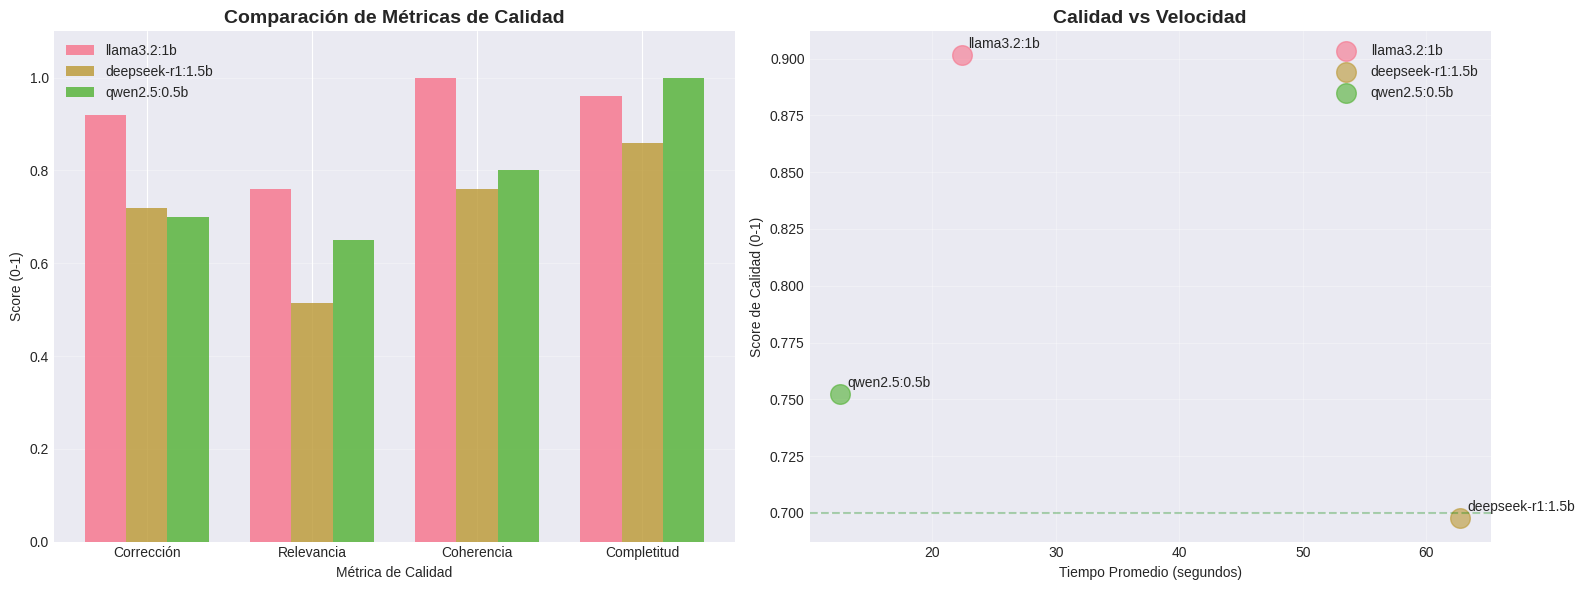

In [9]:
# Gráfico de radar: Métricas de calidad por modelo
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Comparación de métricas de calidad
metrics = ['correctness_score', 'relevance_score', 'coherence_score', 'completeness_score']
metric_names = ['Corrección', 'Relevancia', 'Coherencia', 'Completitud']

model_metrics = df_results.groupby('model')[metrics].mean()

x = np.arange(len(metric_names))
width = 0.25

for i, model in enumerate(models):
    values = model_metrics.loc[model].values
    axes[0].bar(x + i*width, values, width, label=model, alpha=0.8)

axes[0].set_xlabel('Métrica de Calidad')
axes[0].set_ylabel('Score (0-1)')
axes[0].set_title('Comparación de Métricas de Calidad', fontsize=14, fontweight='bold')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metric_names)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, 1.1)

# 2. Score de calidad vs velocidad
summary_data = df_results.groupby('model').agg({
    'quality_score': 'mean',
    'time': 'mean'
})

for model in models:
    quality = summary_data.loc[model, 'quality_score']
    time = summary_data.loc[model, 'time']
    axes[1].scatter(time, quality, s=200, alpha=0.6, label=model)
    axes[1].annotate(model, (time, quality), xytext=(5, 5), textcoords='offset points')

axes[1].set_xlabel('Tiempo Promedio (segundos)')
axes[1].set_ylabel('Score de Calidad (0-1)')
axes[1].set_title('Calidad vs Velocidad', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].legend()

# Línea ideal (arriba-izquierda = mejor)
axes[1].axhline(y=0.7, color='green', linestyle='--', alpha=0.3, label='Calidad mínima aceptable')

plt.tight_layout()
plt.show()

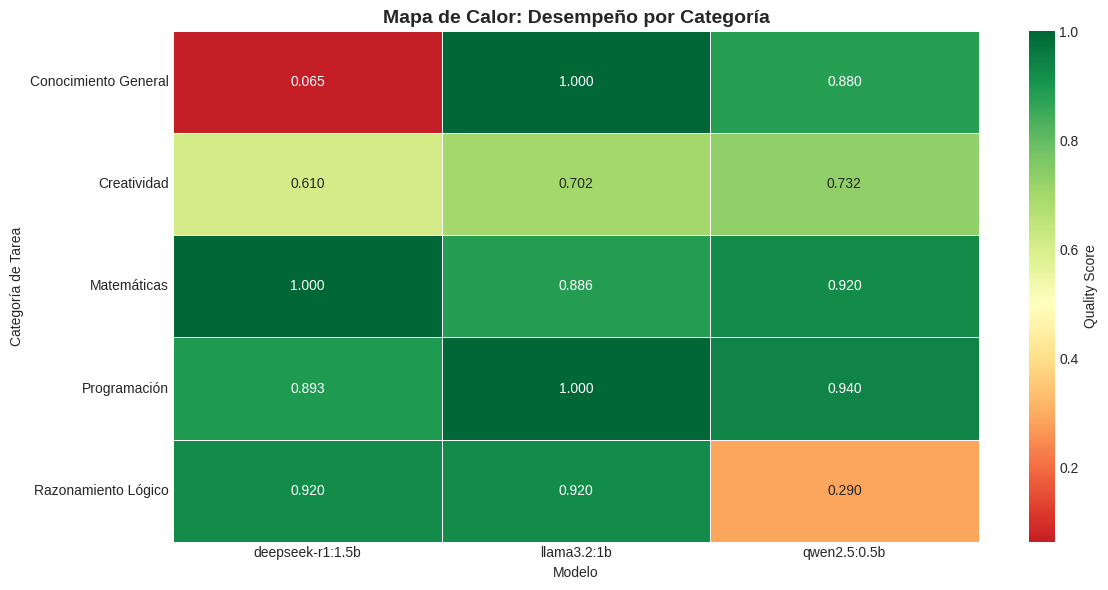

In [10]:
# Heatmap de calidad por categoría
plt.figure(figsize=(12, 6))
sns.heatmap(category_analysis.T, annot=True, fmt='.3f', cmap='RdYlGn', center=0.5,
            cbar_kws={'label': 'Quality Score'}, linewidths=0.5)
plt.title('Mapa de Calor: Desempeño por Categoría', fontsize=14, fontweight='bold')
plt.xlabel('Modelo')
plt.ylabel('Categoría de Tarea')
plt.tight_layout()
plt.show()

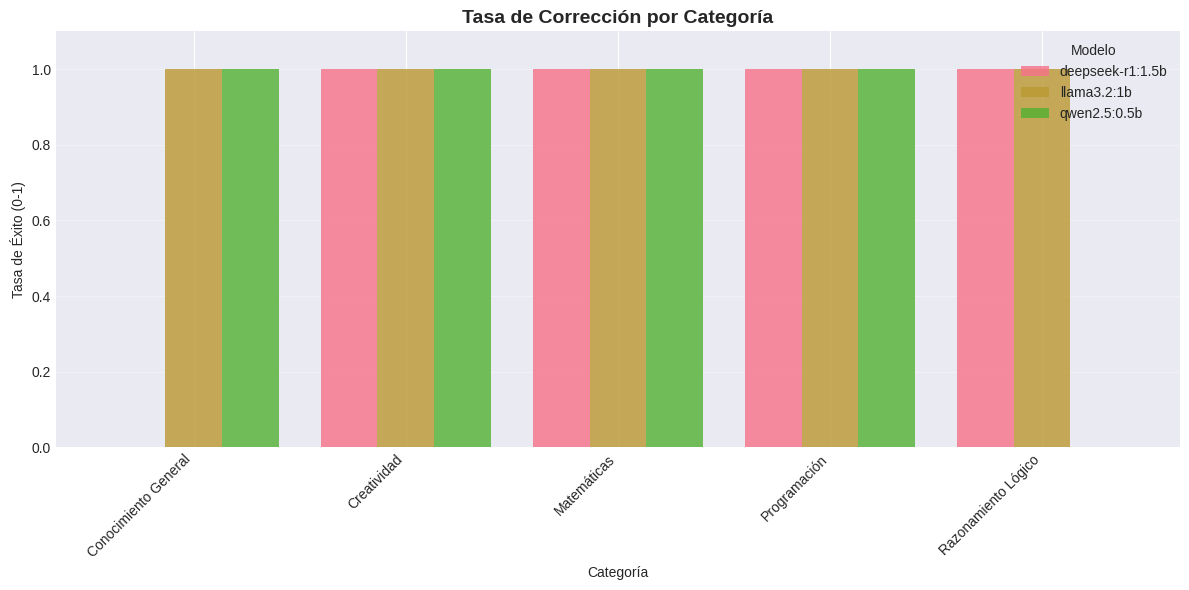

In [11]:
# Tasa de éxito por categoría
success_by_category = df_results.pivot_table(
    index='category',
    columns='model',
    values='correctness_passed',
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(12, 6))
success_by_category.plot(kind='bar', ax=ax, width=0.8, alpha=0.8)
ax.set_title('Tasa de Corrección por Categoría', fontsize=14, fontweight='bold')
ax.set_xlabel('Categoría')
ax.set_ylabel('Tasa de Éxito (0-1)')
ax.set_ylim(0, 1.1)
ax.legend(title='Modelo')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7. Sistema de Scoring Ponderado Profesional

In [12]:
# Calcular score final ponderado considerando múltiples factores
def calculate_final_score(df, model_name):
    """
    Calcula el score final considerando:
    - Calidad de respuestas (peso mayor)
    - Velocidad (peso menor)
    - Consistencia (desviación estándar)
    - Tasa de éxito
    """
    model_data = df[df['model'] == model_name]
    
    # 1. Score de calidad promedio ponderado por importancia de cada test
    weighted_quality = np.average(model_data['quality_score'], weights=model_data['weight'])
    
    # 2. Normalizar velocidad (invertido: más rápido = mejor)
    all_times = df['time'].values
    speed_score = 1 - (model_data['time'].mean() - all_times.min()) / (all_times.max() - all_times.min())
    
    # 3. Consistencia (penalizar alta desviación)
    consistency_score = 1 - min(model_data['quality_score'].std(), 0.5) / 0.5
    
    # 4. Tasa de éxito
    success_rate = model_data['correctness_passed'].mean()
    
    # Score final ponderado
    final_score = (
        weighted_quality * 0.50 +    # Calidad es lo más importante
        success_rate * 0.25 +        # Tasa de éxito
        speed_score * 0.15 +         # Velocidad
        consistency_score * 0.10     # Consistencia
    )
    
    return {
        'model': model_name,
        'final_score': final_score,
        'quality_score': weighted_quality,
        'speed_score': speed_score,
        'consistency_score': consistency_score,
        'success_rate': success_rate
    }

# Calcular scores finales
final_scores = [calculate_final_score(df_results, model) for model in models]
df_final = pd.DataFrame(final_scores).sort_values('final_score', ascending=False)

print("=" * 80)
print("RANKING FINAL DE MODELOS")
print("=" * 80)
print(df_final.to_string(index=False))
print("\n")

best_model = df_final.iloc[0]['model']
best_score = df_final.iloc[0]['final_score']

print("=" * 80)
print(f"🏆 MEJOR MODELO: {best_model}")
print(f"📊 Score Final: {best_score:.3f}")
print("=" * 80)

RANKING FINAL DE MODELOS
           model  final_score  quality_score  speed_score  consistency_score  success_rate
     llama3.2:1b     0.910501       0.919403     0.834715           0.755917           1.0
    qwen2.5:0.5b     0.771558       0.775938     0.918603           0.457990           0.8
deepseek-r1:1.5b     0.663918       0.734152     0.489674           0.233913           0.8


🏆 MEJOR MODELO: llama3.2:1b
📊 Score Final: 0.911


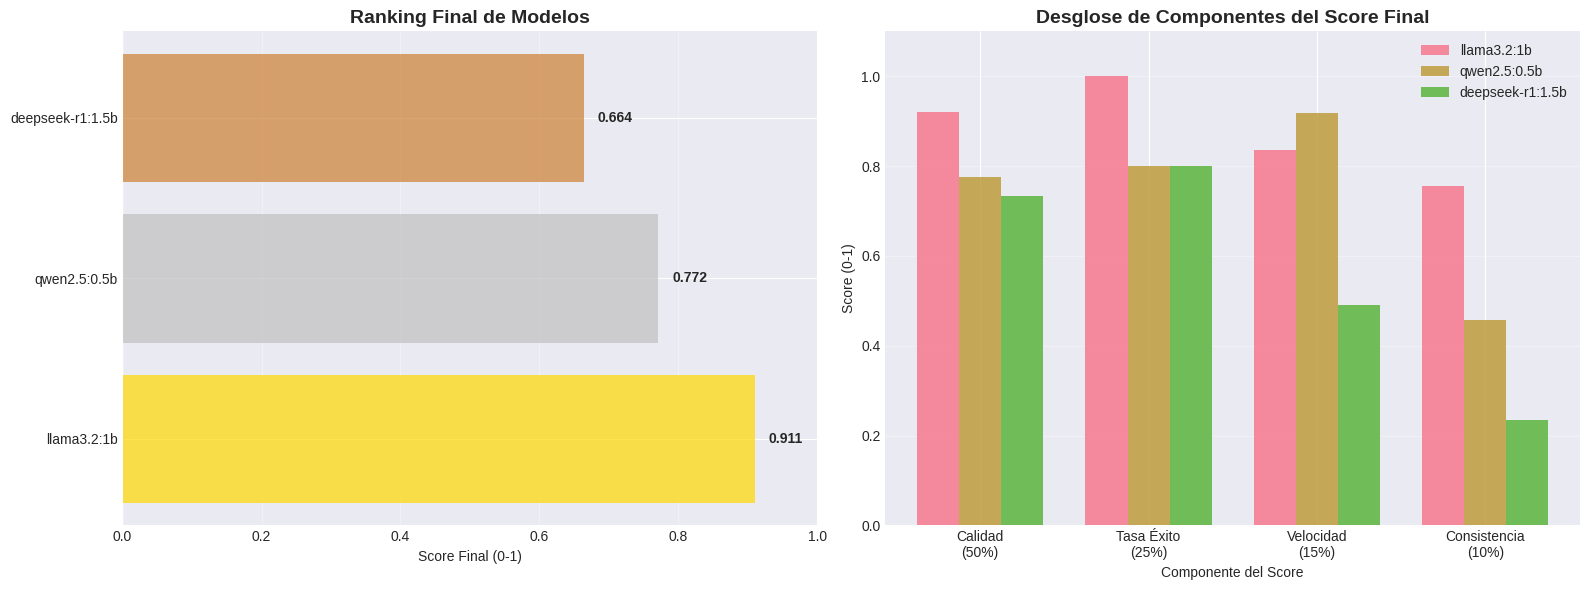

In [13]:
# Visualización de scores finales
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Ranking general
colors = ['gold', 'silver', '#CD7F32']
bars = axes[0].barh(df_final['model'], df_final['final_score'], color=colors, alpha=0.7)
axes[0].set_xlabel('Score Final (0-1)')
axes[0].set_title('Ranking Final de Modelos', fontsize=14, fontweight='bold')
axes[0].set_xlim(0, 1)
axes[0].grid(axis='x', alpha=0.3)

# Agregar valores
for i, bar in enumerate(bars):
    width = bar.get_width()
    axes[0].text(width + 0.02, bar.get_y() + bar.get_height()/2, 
                f'{width:.3f}', ha='left', va='center', fontweight='bold')

# 2. Desglose de componentes del score
components = ['quality_score', 'success_rate', 'speed_score', 'consistency_score']
component_names = ['Calidad', 'Tasa Éxito', 'Velocidad', 'Consistencia']
weights = [0.50, 0.25, 0.15, 0.10]

x = np.arange(len(component_names))
width = 0.25

for i, model in enumerate(df_final['model']):
    model_data = df_final[df_final['model'] == model].iloc[0]
    values = [model_data[comp] for comp in components]
    axes[1].bar(x + i*width, values, width, label=model, alpha=0.8)

axes[1].set_xlabel('Componente del Score')
axes[1].set_ylabel('Score (0-1)')
axes[1].set_title('Desglose de Componentes del Score Final', fontsize=14, fontweight='bold')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels([f"{name}\n({w*100:.0f}%)" for name, w in zip(component_names, weights)])
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

## 8. Análisis Detallado de Respuestas

In [14]:
# Mostrar ejemplos de mejor y peor desempeño por categoría
print("=" * 80)
print("EJEMPLOS DE RESPUESTAS POR CATEGORÍA")
print("=" * 80)

for category in df_results['category'].unique():
    print(f"\n{'='*80}")
    print(f"CATEGORÍA: {category}")
    print(f"{'='*80}\n")
    
    category_data = df_results[df_results['category'] == category].sort_values('quality_score', ascending=False)
    
    # Mejor respuesta
    best = category_data.iloc[0]
    print(f"🏆 MEJOR RESPUESTA: {best['model']} (Score: {best['quality_score']:.3f})")
    print(f"Pregunta: {best['prompt']}")
    print(f"\nEvaluación:")
    print(f"  - Corrección: {best['correctness_score']:.3f} ({best['correctness_reason']})")
    print(f"  - Relevancia: {best['relevance_score']:.3f}")
    print(f"  - Coherencia: {best['coherence_score']:.3f}")
    print(f"  - Completitud: {best['completeness_score']:.3f}")
    print(f"\nRespuesta ({len(best['response'])} caracteres):")
    print("-" * 80)
    # Mostrar solo primeros 500 caracteres si es muy larga
    if len(best['response']) > 500:
        print(best['response'][:500] + "...\n[Respuesta truncada]")
    else:
        print(best['response'])
    
    # Peor respuesta
    worst = category_data.iloc[-1]
    print(f"\n❌ PEOR RESPUESTA: {worst['model']} (Score: {worst['quality_score']:.3f})")
    print(f"\nEvaluación:")
    print(f"  - Corrección: {worst['correctness_score']:.3f} ({worst['correctness_reason']})")
    print(f"  - Relevancia: {worst['relevance_score']:.3f}")
    print(f"  - Coherencia: {worst['coherence_score']:.3f}")
    print(f"  - Completitud: {worst['completeness_score']:.3f}")
    print(f"\nRespuesta ({len(worst['response'])} caracteres):")
    print("-" * 80)
    if len(worst['response']) > 500:
        print(worst['response'][:500] + "...\n[Respuesta truncada]")
    else:
        print(worst['response'])
    print()

EJEMPLOS DE RESPUESTAS POR CATEGORÍA

CATEGORÍA: Razonamiento Lógico

🏆 MEJOR RESPUESTA: llama3.2:1b (Score: 0.920)
Pregunta: Si todos los perros ladran y Max es un perro, ¿qué podemos concluir sobre Max?

Evaluación:
  - Corrección: 0.800 (Presenta razonamiento lógico)
  - Relevancia: 1.000
  - Coherencia: 1.000
  - Completitud: 1.000

Respuesta (220 caracteres):
--------------------------------------------------------------------------------
No podemos concluir nada sobre Max específicamente, ya que solo se nos dice que todos los perros ladran. Sin más información, no hay suficiente datos para llegar a una conclusión precisa sobre Max o cualquier otro perro.

❌ PEOR RESPUESTA: qwen2.5:0.5b (Score: 0.290)

Evaluación:
  - Corrección: 0.000 (Respuesta fallida o rechazada)
  - Relevancia: 0.000
  - Coherencia: 0.700
  - Completitud: 1.000

Respuesta (1084 caracteres):
--------------------------------------------------------------------------------
Lo siento, pero no puedo asumir que "Ma

## 9. Recomendaciones Profesionales

In [15]:
print("=" * 80)
print("RECOMENDACIONES PARA SELECCIÓN DE MODELO")
print("=" * 80)
print()

# Análisis del mejor modelo
best_model_data = df_results[df_results['model'] == best_model]
best_final = df_final.iloc[0]

print(f"🏆 MODELO RECOMENDADO: {best_model}")
print(f"   Score Final: {best_final['final_score']:.3f}\n")

print("📊 MÉTRICAS CLAVE:")
print(f"   • Calidad promedio: {best_final['quality_score']:.3f}")
print(f"   • Tasa de éxito: {best_final['success_rate']:.1%}")
print(f"   • Velocidad: {best_final['speed_score']:.3f}")
print(f"   • Consistencia: {best_final['consistency_score']:.3f}")
print(f"   • Tiempo promedio: {best_model_data['time'].mean():.2f}s\n")

# Fortalezas
category_scores = best_model_data.groupby('category')['quality_score'].mean().sort_values(ascending=False)
print("✅ FORTALEZAS:")
for cat, score in category_scores.head(3).items():
    print(f"   • {cat}: {score:.3f}")
print()

# Debilidades
print("⚠️  ÁREAS DE MEJORA:")
for cat, score in category_scores.tail(2).items():
    print(f"   • {cat}: {score:.3f}")
print()

# Comparación con otros modelos
print("📈 COMPARACIÓN CON ALTERNATIVAS:")
for i in range(1, min(3, len(df_final))):
    alt_model = df_final.iloc[i]
    score_diff = best_final['final_score'] - alt_model['final_score']
    print(f"   vs {alt_model['model']}: +{score_diff:.3f} ({score_diff/alt_model['final_score']*100:.1f}% mejor)")
print()

# Recomendaciones de uso
print("💡 RECOMENDACIONES DE USO:")
print(f"   • Usar {best_model} para aplicaciones de propósito general")

# Recomendar modelo específico por tarea
for category in df_results['category'].unique():
    cat_best = df_results[df_results['category'] == category].sort_values('quality_score', ascending=False).iloc[0]
    if cat_best['model'] != best_model:
        print(f"   • Para {category}, considerar {cat_best['model']} (score: {cat_best['quality_score']:.3f})")

print()
print("=" * 80)

RECOMENDACIONES PARA SELECCIÓN DE MODELO

🏆 MODELO RECOMENDADO: llama3.2:1b
   Score Final: 0.911

📊 MÉTRICAS CLAVE:
   • Calidad promedio: 0.919
   • Tasa de éxito: 100.0%
   • Velocidad: 0.835
   • Consistencia: 0.756
   • Tiempo promedio: 22.38s

✅ FORTALEZAS:
   • Conocimiento General: 1.000
   • Programación: 1.000
   • Razonamiento Lógico: 0.920

⚠️  ÁREAS DE MEJORA:
   • Matemáticas: 0.886
   • Creatividad: 0.703

📈 COMPARACIÓN CON ALTERNATIVAS:
   vs qwen2.5:0.5b: +0.139 (18.0% mejor)
   vs deepseek-r1:1.5b: +0.247 (37.1% mejor)

💡 RECOMENDACIONES DE USO:
   • Usar llama3.2:1b para aplicaciones de propósito general
   • Para Matemáticas, considerar deepseek-r1:1.5b (score: 1.000)
   • Para Creatividad, considerar qwen2.5:0.5b (score: 0.733)



## 10. Exportar Resultados Detallados

In [ ]:
import os

results_dir = '../results'
os.makedirs(results_dir, exist_ok=True)

# Exportar resultados detallados
df_results.to_csv(f'{results_dir}/quality_evaluation_detailed.csv', index=False)
quality_summary.to_csv(f'{results_dir}/quality_summary.csv')
category_analysis.to_csv(f'{results_dir}/category_analysis.csv')
df_final.to_csv(f'{results_dir}/final_scores.csv', index=False)

# Exportar reporte en JSON
report = {
    'timestamp': datetime.now().isoformat(),
    'best_model': best_model,
    'final_scores': df_final.to_dict(orient='records'),
    'quality_metrics': quality_summary.to_dict(),
    'category_performance': category_analysis.to_dict(),
    'detailed_results': df_results.to_dict(orient='records')
}

with open(f'{results_dir}/quality_evaluation_report.json', 'w', encoding='utf-8') as f:
    json.dump(report, f, indent=2, ensure_ascii=False)

print("✓ Resultados exportados:")
print(f"  • {results_dir}/quality_evaluation_detailed.csv")
print(f"  • {results_dir}/quality_summary.csv")
print(f"  • {results_dir}/category_analysis.csv")
print(f"  • {results_dir}/final_scores.csv")
print(f"  • {results_dir}/quality_evaluation_report.json")

TypeError: keys must be str, int, float, bool or None, not tuple

## Conclusiones

Este notebook implementa un sistema profesional de evaluación de LLMs que considera:

### Métricas de Calidad Implementadas:
1. **Corrección (40%)**: Validación de respuestas correctas según la tarea
2. **Relevancia (25%)**: Pertinencia de la respuesta a la pregunta
3. **Coherencia (20%)**: Lógica interna y ausencia de contradicciones
4. **Completitud (15%)**: Nivel de detalle y exhaustividad

### Sistema de Scoring Final:
1. **Calidad ponderada (50%)**: Métrica más importante
2. **Tasa de éxito (25%)**: Proporción de respuestas correctas
3. **Velocidad (15%)**: Tiempo de respuesta
4. **Consistencia (10%)**: Estabilidad en el desempeño

### Ventajas sobre Evaluación Simple:
- ✅ Evaluación multi-dimensional de calidad
- ✅ Validación específica por tipo de tarea
- ✅ Detección de fallos y alucinaciones
- ✅ Análisis de fortalezas/debilidades por categoría
- ✅ Recomendaciones basadas en datos objetivos
- ✅ No solo considera velocidad, sino calidad real de respuestas

Este enfoque permite seleccionar el modelo más apropiado basándose en criterios profesionales, no solo en métricas superficiales como velocidad o longitud de respuesta.